# Notebook 1 — Build Feature Matrix

Parse all 314 MAG `.fa.gz` files and compute:
- **4-mer frequencies** → shape `(314, 256)` — main feature matrix
- **Metadata** → genome size, GC content, contig count per MAG

Output saved to `data/` and used by all downstream notebooks.

## 1. Imports

In [2]:
import gzip
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

## 2. Download dataset (runs only if data not present)

In [3]:
import urllib.request
import tarfile
import os

DATASET_URL  = "https://swifter.embl.de/~fullam/spire/compiled/David_2015_Bangladesh_spire_v1_MAGs.tar"
RAW_DIR      = Path("data/raw_David_2015_bangladesh")
TAR_PATH     = Path("data/David_2015_Bangladesh_spire_v1_MAGs.tar")

def _progress(block_num, block_size, total_size):
    downloaded = block_num * block_size
    pct = min(downloaded / total_size * 100, 100)
    bar = "#" * int(pct // 2)
    print(f"\r  [{bar:<50}] {pct:.1f}%  ({downloaded/1e6:.1f} / {total_size/1e6:.0f} MB)", end="", flush=True)

# Only download + extract if the raw directory is missing or empty
if RAW_DIR.exists() and len(list(RAW_DIR.glob("*.fa.gz"))) > 0:
    print(f"Data already present — {len(list(RAW_DIR.glob('*.fa.gz')))} files in {RAW_DIR}")
else:
    RAW_DIR.mkdir(parents=True, exist_ok=True)

    if not TAR_PATH.exists():
        print(f"Downloading dataset (~137 MB) from EMBL SPIRE...")
        urllib.request.urlretrieve(DATASET_URL, TAR_PATH, reporthook=_progress)
        print(f"\nDownload complete: {TAR_PATH}")
    else:
        print(f"Tar file already downloaded: {TAR_PATH}")

    print("Extracting...")
    with tarfile.open(TAR_PATH) as tar:
        members = tar.getmembers()
        for i, member in enumerate(members):
            tar.extract(member, path=RAW_DIR)
            print(f"\r  Extracted {i+1}/{len(members)} files", end="", flush=True)
    print(f"\nExtraction complete — {len(list(RAW_DIR.glob('*.fa.gz')))} .fa.gz files in {RAW_DIR}")

    # Remove tar to save disk space
    TAR_PATH.unlink()
    print(f"Removed tar file to save space.")

Data already present — 314 files in data\raw_David_2015_bangladesh


## 3. Paths

In [4]:
DATA_DIR = RAW_DIR          # set in the download cell above
OUT_DIR  = Path("data")

fasta_files = sorted(DATA_DIR.glob("*.fa.gz"))
print(f"Found {len(fasta_files)} MAG files")

Found 314 MAG files


## 3b. What does one MAG file look like?

In [6]:
import gzip

example_file = fasta_files[0]
print(f"File: {example_file.name}")
print(f"Size on disk: {example_file.stat().st_size / 1024:.1f} KB (compressed)\n")

with gzip.open(example_file, "rt") as f:
    lines = f.readlines()

# Count contigs and total bases
headers = [l.strip() for l in lines if l.startswith(">")]
sequences = [l.strip() for l in lines if not l.startswith(">")]
total_bases = sum(len(s) for s in sequences)

print(f"Total contigs : {len(headers)}")
print(f"Total bases   : {total_bases:,}")
print()

# Show first 3 contigs
print("First 3 contig headers:")
for h in headers[:3]:
    print(f"  {h}")
print()

# Show a snippet of the first sequence line
first_seq_line = next(l.strip() for l in lines if not l.startswith(">"))
print(f"First sequence line (first 80 base pair):")
print(f"  {first_seq_line[:80]}...")

File: spire_mag_01923446.fa.gz
Size on disk: 71.4 KB (compressed)

Total contigs : 15
Total bases   : 232,121

First 3 contig headers:
  >k119_1729
  >k119_3850
  >k119_399

First sequence line (first 80 base pair):
  GTGGCACAGGGAACCCGCCACAGCATGAAAGCGTCATCGGACAATAACGACTTCCGCGCC...


## 4. Hypotheses

Before running any analysis, I reviewed existing research on bacterial DNA composition and gut microbiome dynamics and formulated 4 hypotheses that this dataset should let us test.

---

### H1 — Disease phase leaves a detectable genomic signature

> MAGs collected during acute cholera infection are separable from recovery-phase MAGs based on k-mer composition alone.

**What it means in plain English:** Cholera infection drastically reshapes which bacteria live in your gut — it wipes out many normal residents and lets other types bloom. If this shift is strong enough, the DNA fingerprints of bacteria sampled during infection should look different from those sampled weeks later during recovery. We are asking: can we *see* the disease timeline just from raw DNA patterns, without any clinical labels?

**Research behind it:**
- [Hsiao et al. 2014, *Nature*](https://doi.org/10.1038/nature13738) — showed that *Ruminococcus obeum* restricts *V. cholerae* colonisation via quorum sensing, identifying specific recovery-phase taxa that return after cholera.
- Subramanian et al. (2014, *Cell*) — demonstrated that the gut microbiome undergoes a structured, predictable recovery after severe diarrheal disease in Bangladeshi children.

---

### H2 — Bacteria from the same evolutionary family cluster together in k-mer space

> MAGs belonging to the same bacterial phylum (broad evolutionary group) will naturally group together when we compare their 4-mer frequency vectors.

**What it means in plain English:** Think of k-mer frequencies as a DNA "accent." Just like people from the same region tend to speak with a similar accent, bacteria that evolved together tend to use similar DNA letter patterns. We are asking: is this accent strong enough that we can group bacteria by family *without ever telling the algorithm any taxonomy labels*?

**Research behind it:**
- Karlin & Burge (1995, *PNAS*) — first described the "genomic signature": each species has a characteristic k-mer usage pattern that is stable across the genome.
- Karlin (1999, *Trends in Genetics*) — confirmed this signature is consistent within a genus/phylum and distinct across phyla.

---

### H3 — GC content is the dominant driver of k-mer cluster structure

> The fraction of G and C bases in a genome (GC content) co-varies strongly with k-mer cluster assignment.

**What it means in plain English:** DNA is made of 4 letters: A, T, G, C. Some bacteria naturally use more G and C; others use more A and T. This preference is so strong that it shows up across thousands of k-mers at once. We predict that when we cluster MAGs by k-mer patterns, what we are really finding — at least as the first and strongest signal — is just this G/C preference, not anything more subtle.

**Research behind it:**
- Karlin & Burge (1995, *PNAS*) — established that GC content is the single most influential factor in genome-wide k-mer composition.
- Teeling et al. (2004, *Environmental Microbiology*) — applied k-mer composition to metagenomic binning and showed GC content dominates the first principal component.

---

### H4 — Longer k-mers (k=4) capture more biological structure than shorter ones (k=2 or k=3)

> The 4-mer feature matrix will produce better-separated clusters than 2-mer or 3-mer matrices.

**What it means in plain English:** A 2-mer is just two letters (e.g. "AC"), and there are only 16 possible ones. A 4-mer is four letters (e.g. "ACGT"), giving 256 possibilities — a much richer vocabulary. More letters = more context = more information about the specific DNA style of each bacterium. We predict that this extra detail leads to tighter, more meaningful clusters.

**Research behind it:**
- Teeling et al. (2004, *Environmental Microbiology*) — specifically argued that k=4 is the practical sweet spot for metagenomic composition analysis: long enough to be species-informative, short enough to count reliably even on fragmented partial genomes like MAGs.

## 3. Helper functions

In [4]:
def parse_fasta_gz(filepath):
    """Return list of (header, sequence) tuples from a gzipped FASTA file."""
    records = []
    header, seq_parts = None, []
    with gzip.open(filepath, "rt") as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if header is not None:
                    records.append((header, "".join(seq_parts)))
                header, seq_parts = line[1:], []
            else:
                seq_parts.append(line.upper())
    if header is not None:
        records.append((header, "".join(seq_parts)))
    return records


# Build the fixed 256-element vocabulary of all 4-mers
BASES = "ACGT"
KMERS = ["".join(p) for p in itertools.product(BASES, repeat=4)]
KMER_INDEX = {km: i for i, km in enumerate(KMERS)}
print(f"Vocabulary size: {len(KMERS)} 4-mers")
print(f"First 8: {KMERS[:8]}")


def kmer_frequencies(sequence, k=4):
    """Return normalised k-mer frequency vector (length 4^k) for a sequence."""
    counts = np.zeros(len(KMERS), dtype=np.float32)
    for i in range(len(sequence) - k + 1):
        kmer = sequence[i:i+k]
        idx = KMER_INDEX.get(kmer)   # None if kmer contains N or other ambiguous bases
        if idx is not None:
            counts[idx] += 1
    total = counts.sum()
    if total > 0:
        counts /= total
    return counts

Vocabulary size: 256 4-mers
First 8: ['AAAA', 'AAAC', 'AAAG', 'AAAT', 'AACA', 'AACC', 'AACG', 'AACT']


## 4. Process all MAGs

For each file:
1. Parse all contigs
2. Concatenate into one genome sequence
3. Compute 4-mer frequencies
4. Record metadata (contig count, total size, GC content)

In [5]:
feature_matrix = []
metadata_rows  = []

for filepath in tqdm(fasta_files, desc="Processing MAGs"):
    records = parse_fasta_gz(filepath)

    # Concatenate all contigs into one genome sequence
    genome_seq = "".join(seq for _, seq in records)

    # 4-mer feature vector
    freq_vec = kmer_frequencies(genome_seq, k=4)
    feature_matrix.append(freq_vec)

    # Metadata
    contig_lengths = [len(seq) for _, seq in records]
    gc_count = genome_seq.count("G") + genome_seq.count("C")
    genome_size = len(genome_seq)
    gc_content = gc_count / genome_size if genome_size > 0 else 0.0

    metadata_rows.append({
        "mag_id":        filepath.stem.replace(".fa", ""),
        "n_contigs":     len(records),
        "genome_size":   genome_size,
        "gc_content":    round(gc_content, 4),
        "contig_len_mean": round(np.mean(contig_lengths), 1),
        "contig_len_max":  max(contig_lengths),
    })

X = np.array(feature_matrix)          # shape (314, 256)
meta = pd.DataFrame(metadata_rows)

print(f"Feature matrix shape: {X.shape}")
print(f"Any NaN: {np.isnan(X).any()}")
meta.head()

Processing MAGs: 100%|██████████| 314/314 [02:36<00:00,  2.01it/s]

Feature matrix shape: (314, 256)
Any NaN: False


,mag_id,n_contigs,genome_size,gc_content,contig_len_mean,contig_len_max
0,spire_mag_01923446,15,232121,0.4676,15474.7,43124
1,spire_mag_01923447,122,1948160,0.5038,15968.5,100136
2,spire_mag_01923448,80,1381358,0.5149,17267.0,54624
3,spire_mag_01923449,24,851807,0.3773,35492.0,116178
4,spire_mag_01923450,17,1236600,0.3710,72741.2,180847


## 5. Save to disk

In [6]:
np.save(OUT_DIR / "kmer4_features.npy", X)
np.save(OUT_DIR / "kmer4_names.npy", np.array(KMERS))
meta.to_csv(OUT_DIR / "metadata.csv", index=False)

print("Saved:")
print(f"  data/kmer4_features.npy  {X.shape}")
print(f"  data/kmer4_names.npy     {len(KMERS)} k-mer labels")
print(f"  data/metadata.csv        {len(meta)} rows")

Saved:
  data/kmer4_features.npy  (314, 256)
  data/kmer4_names.npy     256 k-mer labels
  data/metadata.csv        314 rows


## 6. Sanity checks

In [7]:
# Each row should sum to 1.0 (frequencies)
row_sums = X.sum(axis=1)
print(f"Row sums — min: {row_sums.min():.4f}, max: {row_sums.max():.4f}, mean: {row_sums.mean():.4f}")

Row sums — min: 1.0000, max: 1.0000, mean: 1.0000


In [8]:
# Metadata summary
meta.describe().round(2)

,n_contigs,genome_size,gc_content,contig_len_mean,contig_len_max
count,314.00,314.00,314.00,314.00,314.00
mean,144.89,1459040.54,0.44,23343.73,86754.12
std,157.34,1269486.17,0.08,31780.91,96122.82
min,1.00,201260.00,0.26,3182.40,4442.00
25%,41.00,444199.00,0.38,4918.25,18985.75
50%,91.50,1162442.00,0.45,10235.85,49169.50
75%,201.00,1984086.25,0.50,28535.38,113965.50
max,1199.00,8667358.00,0.61,293686.00,489301.00


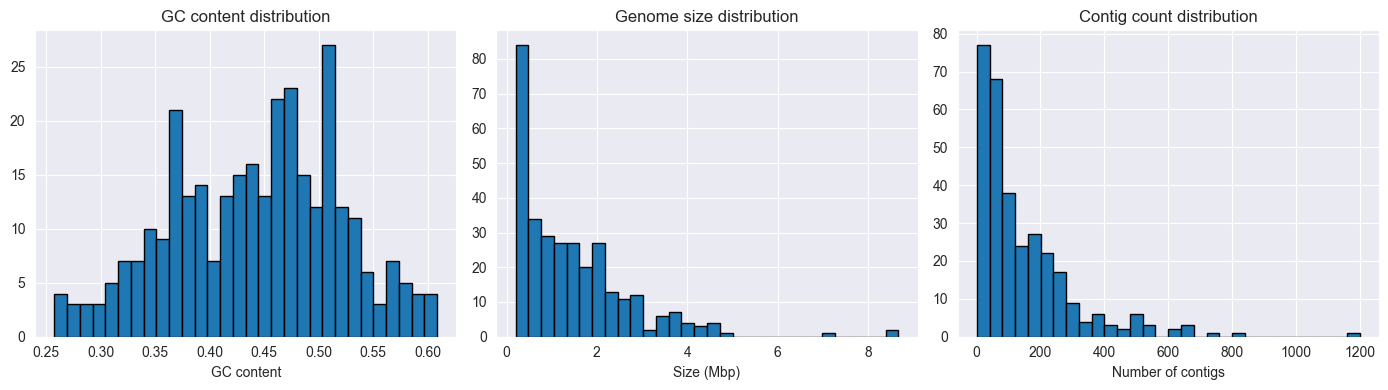

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(meta["gc_content"], bins=30, edgecolor="k")
axes[0].set_title("GC content distribution")
axes[0].set_xlabel("GC content")

axes[1].hist(meta["genome_size"] / 1e6, bins=30, edgecolor="k")
axes[1].set_title("Genome size distribution")
axes[1].set_xlabel("Size (Mbp)")

axes[2].hist(meta["n_contigs"], bins=30, edgecolor="k")
axes[2].set_title("Contig count distribution")
axes[2].set_xlabel("Number of contigs")

plt.tight_layout()
plt.savefig(OUT_DIR / "metadata_distributions.png", dpi=150)
plt.show()

In [10]:

# Show the 10 most variable 4-mers across genomes
kmer_variance = X.var(axis=0)
top10_idx = np.argsort(kmer_variance)[::-1][:10]
print("Most variable 4-mers:")
for i in top10_idx:
    print(f"  {KMERS[i]}  variance={kmer_variance[i]:.6f}")

Most variable 4-mers:
  AAAA  variance=0.000049
  TTTT  variance=0.000046
  AAAT  variance=0.000025
  ATTT  variance=0.000025
  TAAA  variance=0.000018
  TTTA  variance=0.000018
  AATT  variance=0.000017
  ATAT  variance=0.000014
  AATA  variance=0.000012
  TATT  variance=0.000012
